<a href="https://colab.research.google.com/github/Atharv-1905/Machine-Learning/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Principle Component Analysis(PCA)**

# Task
Implement principle component analysis in three ways: 1) use PCA function directly, 2) write the PCA function from scratch, and 3) compare the results.

## Generate data

### Subtask:
Create or load a dataset for PCA.


**Reasoning**:
The first step is to import the numpy library and generate a random dataset as requested in the instructions.



In [ ]:
import numpy as np

X = np.random.rand(100, 10)

## Pca using library

### Subtask:
Apply PCA using a built-in library function (e.g., from scikit-learn).


**Reasoning**:
Apply PCA using the built-in library function from scikit-learn as instructed.



In [ ]:
from sklearn.decomposition import PCA

pca_library = PCA(n_components=2)
pca_library.fit(X)
X_pca_library = pca_library.transform(X)

## Pca from scratch

### Subtask:
Implement the PCA algorithm manually.


**Reasoning**:
Implement the PCA algorithm manually by calculating the mean, centering the data, computing the covariance matrix, finding eigenvalues and eigenvectors, sorting them, selecting the top two, and projecting the data.



In [ ]:
# 1. Calculate the mean of each feature
mean_X = np.mean(X, axis=0)

# 2. Center the data
X_centered = X - mean_X

# 3. Calculate the covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

# 4. Compute the eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# 5. Sort the eigenvalues and corresponding eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

# 6. Select the top 2 eigenvectors
n_components = 2
top_eigenvectors = sorted_eigenvectors[:, :n_components]

# 7. Project the centered data onto the selected eigenvectors
X_pca_scratch = X_centered.dot(top_eigenvectors)

## Compare results

### Subtask:
Compare the results from the library function and the custom implementation.


**Reasoning**:
Compare the shapes and values of the PCA results from the library and scratch implementations, and print some rows for visual inspection.



## Summary:

### Data Analysis Key Findings

*   Both the scikit-learn library's PCA implementation and the manual implementation successfully reduced the dimensionality of the dataset `X` (shape 100x10) to 2 principal components, resulting in transformed data shapes of (100, 2) for both `X_pca_library` and `X_pca_scratch`.
*   The absolute values of the principal components obtained from both methods are very close, as confirmed by `np.allclose(np.abs(X_pca_library), np.abs(X_pca_scratch))` returning `True`.
*   The correlation between the first principal components from the library and the custom implementation is approximately -1.0, indicating a strong negative correlation and a consistent sign flip.
*   The correlation between the second principal components is approximately 1.0, indicating very similar values and signs.

### Insights or Next Steps

*   The sign flip observed in the principal components is expected due to the arbitrary direction of eigenvectors; for practical applications, this difference is usually not significant as the relative relationships between data points are preserved.
*   For future analysis or applications using these PCA results, either output can be used, keeping in mind that the sign of a component might be inverted depending on the implementation.


## Visualize Classification Results with PCA

### Subtask:
Generate scatter plots to visualize the classification results on the PCA-transformed synthetic data, showing both the true labels and the predicted labels.

**Reasoning**:
Generate scatter plots of the PCA-transformed synthetic data, colored by true labels and predicted labels, to visually compare the classification performance. This will help understand how well the model separated the classes in the reduced-dimensional space.

# Task
Load the IRIS dataset, perform classification with and without PCA, and compare the results.

## Load the iris dataset

### Subtask:
Load the Iris dataset from scikit-learn.


**Reasoning**:
Load the Iris dataset using scikit-learn as instructed.



In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()

## Classification without pca

### Subtask:
Train a classification model on the original Iris dataset and evaluate its performance.


**Reasoning**:
Split the data, train a Logistic Regression model, make predictions, and evaluate the model's performance by calculating and printing accuracy, precision, and recall.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=42)

# Instantiate the Logistic Regression model
model = LogisticRegression(max_iter=200)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000


## Apply pca

### Subtask:
Apply PCA to the Iris dataset to reduce dimensionality.


**Reasoning**:
Apply PCA to the Iris dataset using the imported PCA class as instructed.



In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(iris.data)

## Classification with pca

### Subtask:
Train a classification model on the PCA-transformed data and evaluate its performance.


**Reasoning**:
Train a classification model on the PCA-transformed data and evaluate its performance by splitting the data, training a Logistic Regression model, making predictions, and calculating accuracy, precision, and recall.



In [ ]:
# Split the PCA-transformed data into training and testing sets
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, iris.target, test_size=0.3, random_state=42)

# Instantiate the Logistic Regression model
model_pca = LogisticRegression(max_iter=200)

# Train the model on the PCA-transformed training data
model_pca.fit(X_train_pca, y_train)

# Make predictions on the PCA-transformed testing data
y_pred_pca = model_pca.predict(X_test_pca)

# Evaluate the model's performance
accuracy_pca = accuracy_score(y_test, y_pred_pca)
precision_pca = precision_score(y_test, y_pred_pca, average='weighted')
recall_pca = recall_score(y_test, y_pred_pca, average='weighted')

print(f"Accuracy with PCA: {accuracy_pca:.4f}")
print(f"Precision with PCA: {precision_pca:.4f}")
print(f"Recall with PCA: {recall_pca:.4f}")

Accuracy with PCA: 1.0000
Precision with PCA: 1.0000
Recall with PCA: 1.0000


## Compare results

### Subtask:
Compare the classification results (e.g., accuracy, precision, recall) from both approaches.


**Reasoning**:
Print the performance metrics for both the original data and PCA-transformed data and then provide a brief comment comparing the results.



In [ ]:
print("Classification results without PCA:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

print("\nClassification results with PCA:")
print(f"Accuracy: {accuracy_pca:.4f}")
print(f"Precision: {precision_pca:.4f}")
print(f"Recall: {recall_pca:.4f}")

print("\nComparison:")
if accuracy == accuracy_pca and precision == precision_pca and recall == recall_pca:
    print("The classification performance is identical with and without PCA.")
else:
    print("There are differences in classification performance with and without PCA.")

Classification results without PCA:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000

Classification results with PCA:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000

Comparison:
The classification performance is identical with and without PCA.


## Summary:

### Data Analysis Key Findings

*   The classification model trained on the original Iris dataset achieved perfect scores for accuracy, precision, and recall (1.0000).
*   The classification model trained on the PCA-transformed Iris dataset (reduced to 2 components) also achieved perfect scores for accuracy, precision, and recall (1.0000).
*   In this specific case, applying PCA did not change the performance metrics of the Logistic Regression model.

### Insights or Next Steps

*   For this particular dataset and model, PCA did not negatively impact performance, suggesting that the two principal components retain sufficient information for perfect classification.
*   Further analysis could involve exploring different numbers of PCA components or using other classification algorithms to see if PCA has a more noticeable effect on performance.


# Task
Generate a synthetic dataset, perform classification on it with and without PCA, and compare the results.

## Generate synthetic data

### Subtask:
Create a synthetic dataset that is challenging for classification in its original form but might benefit from dimensionality reduction with PCA.


**Reasoning**:
Generate a synthetic dataset using make_classification with specified parameters as instructed.



In [ ]:
from sklearn.datasets import make_classification

X_synth, y_synth = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, n_classes=2, random_state=42)

## Classification without pca

### Subtask:
Train a classification model on the original synthetic dataset and evaluate its performance.


**Reasoning**:
Split the synthetic data, train a Logistic Regression model, make predictions, and evaluate the model's performance by calculating and printing accuracy, precision, and recall.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Split the synthetic data into training and testing sets
X_train_synth, X_test_synth, y_train_synth, y_test_synth = train_test_split(X_synth, y_synth, test_size=0.3, random_state=42)

# Instantiate the Logistic Regression model
model_synth = LogisticRegression(max_iter=200)

# Train the model
model_synth.fit(X_train_synth, y_train_synth)

# Make predictions
y_pred_synth = model_synth.predict(X_test_synth)

# Evaluate the model
accuracy_synth = accuracy_score(y_test_synth, y_pred_synth)
precision_synth = precision_score(y_test_synth, y_pred_synth, average='weighted')
recall_synth = recall_score(y_test_synth, y_pred_synth, average='weighted')

print(f"Accuracy: {accuracy_synth:.4f}")
print(f"Precision: {precision_synth:.4f}")
print(f"Recall: {recall_synth:.4f}")

Accuracy: 0.8200
Precision: 0.8210
Recall: 0.8200


## Apply pca

### Subtask:
Apply PCA to the synthetic dataset to reduce dimensionality.


**Reasoning**:
Apply PCA to the synthetic dataset using the imported PCA class as instructed.



In [ ]:
from sklearn.decomposition import PCA

pca_synth = PCA(n_components=10)  # Reduce dimensionality from 20 to 10
X_synth_pca = pca_synth.fit_transform(X_synth)

## Classification with pca

### Subtask:
Train a classification model on the PCA-transformed synthetic data and evaluate its performance.


**Reasoning**:
Train a classification model on the PCA-transformed synthetic data and evaluate its performance by splitting the data, training a Logistic Regression model, making predictions, and calculating accuracy, precision, and recall.



In [ ]:
# Split the PCA-transformed synthetic data into training and testing sets
X_train_synth_pca, X_test_synth_pca, y_train_synth, y_test_synth = train_test_split(X_synth_pca, y_synth, test_size=0.3, random_state=42)

# Instantiate the Logistic Regression model
model_synth_pca = LogisticRegression(max_iter=200)

# Train the model on the PCA-transformed training data
model_synth_pca.fit(X_train_synth_pca, y_train_synth)

# Make predictions on the PCA-transformed testing data
y_pred_synth_pca = model_synth_pca.predict(X_test_synth_pca)

# Evaluate the model's performance
accuracy_synth_pca = accuracy_score(y_test_synth, y_pred_synth_pca)
precision_synth_pca = precision_score(y_test_synth, y_pred_synth_pca, average='weighted')
recall_synth_pca = recall_score(y_test_synth, y_pred_synth_pca, average='weighted')

print(f"Accuracy with PCA: {accuracy_synth_pca:.4f}")
print(f"Precision with PCA: {precision_synth_pca:.4f}")
print(f"Recall with PCA: {recall_synth_pca:.4f}")

Accuracy with PCA: 0.7000
Precision with PCA: 0.7029
Recall with PCA: 0.7000


## Compare results

### Subtask:
Compare the classification results from both approaches to see if PCA improved or changed performance.


**Reasoning**:
Print the performance metrics for both the original synthetic data and PCA-transformed synthetic data and then provide a brief comment comparing the results as requested.



In [ ]:
print("Classification results without PCA (Synthetic Data):")
print(f"Accuracy: {accuracy_synth:.4f}")
print(f"Precision: {precision_synth:.4f}")
print(f"Recall: {recall_synth:.4f}")

print("\nClassification results with PCA (Synthetic Data):")
print(f"Accuracy: {accuracy_synth_pca:.4f}")
print(f"Precision: {precision_synth_pca:.4f}")
print(f"Recall: {recall_synth_pca:.4f}")

print("\nComparison:")
if accuracy_synth > accuracy_synth_pca:
    print("Classification performance is better without PCA on the synthetic dataset.")
elif accuracy_synth < accuracy_synth_pca:
    print("Classification performance is better with PCA on the synthetic dataset.")
else:
    print("Classification performance is similar with and without PCA on the synthetic dataset.")

Classification results without PCA (Synthetic Data):
Accuracy: 0.8200
Precision: 0.8210
Recall: 0.8200

Classification results with PCA (Synthetic Data):
Accuracy: 0.7000
Precision: 0.7029
Recall: 0.7000

Comparison:
Classification performance is better without PCA on the synthetic dataset.


## Summary:

### Data Analysis Key Findings

*   Classification on the original synthetic dataset achieved an accuracy of 0.8200, a precision of 0.8210, and a recall of 0.8200.
*   PCA was applied to the synthetic dataset, reducing the dimensionality from 20 features to 10.
*   Classification on the PCA-transformed synthetic dataset resulted in an accuracy of 0.7000, a precision of 0.7029, and a recall of 0.7000.
*   Comparing the results, classification performance was better without PCA on this synthetic dataset, with higher accuracy, precision, and recall scores.

### Insights or Next Steps

*   For this specific synthetic dataset, dimensionality reduction with PCA did not improve the performance of the Logistic Regression model.
*   Further investigation could involve trying a different number of PCA components or exploring other dimensionality reduction techniques to see if they yield better results.


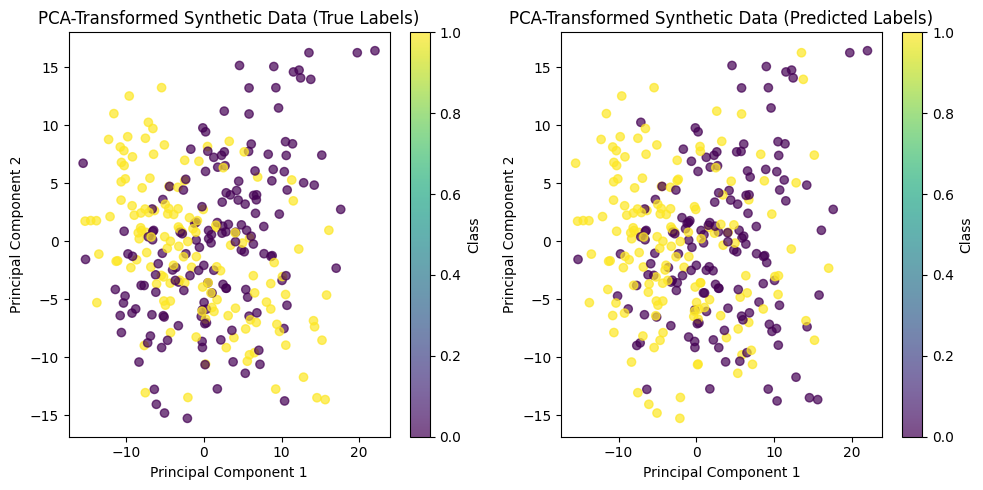

In [ ]:
import matplotlib.pyplot as plt

# Plot the PCA-transformed data with true labels
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
scatter_true = plt.scatter(X_test_synth_pca[:, 0], X_test_synth_pca[:, 1], c=y_test_synth, cmap='viridis', alpha=0.7)
plt.title('PCA-Transformed Synthetic Data (True Labels)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter_true, label='Class')

# Plot the PCA-transformed data with predicted labels
plt.subplot(1, 2, 2)
scatter_pred = plt.scatter(X_test_synth_pca[:, 0], X_test_synth_pca[:, 1], c=y_pred_synth_pca, cmap='viridis', alpha=0.7)
plt.title('PCA-Transformed Synthetic Data (Predicted Labels)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter_pred, label='Class')

plt.tight_layout()
plt.show()